In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

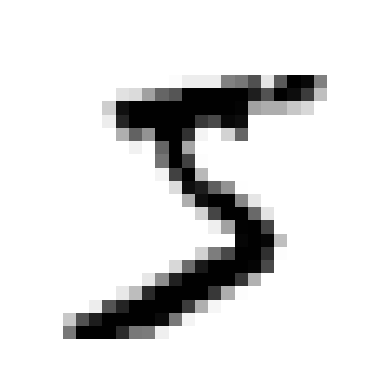

In [2]:
X, y = mnist.data, mnist.target

def plot_digit(image_data:np.ndarray):
    image = image_data.reshape(28,28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)
plt.show()

In [3]:
#from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [16]:
from sklearn.model_selection import cross_val_predict, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

k_grid = {'n_neighbors': [1,3,5,10,15,20,25,30]}
clf_knn = grid_search = GridSearchCV(KNeighborsClassifier(), k_grid, cv=3, n_jobs=-1)
grid_search.fit(X_train, y_train)

e:\Program\handson-mlp\.venv\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [       nan        nan        nan 0.96295238 0.95961905 0.95672381
        nan        nan]
  warnings.warn(


,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': [1, 3, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,10


In [ ]:
print(grid_search.best_params_)

{'n_neighbors': 3}


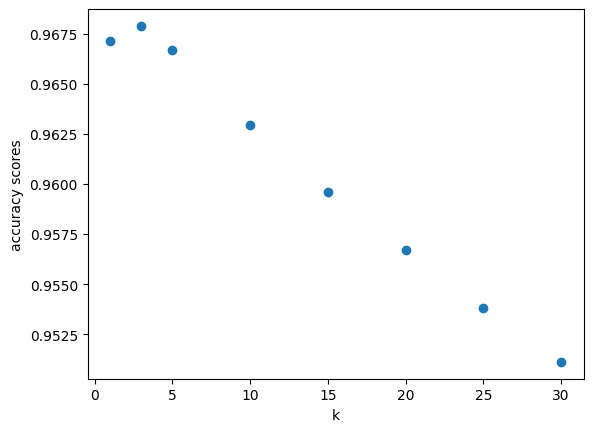

In [ ]:
from sklearn.metrics import f1_score

results = grid_search.cv_results_
k_values = [p['n_neighbors'] for p in results['params']]
accuracy_scores = results['mean_test_score']

plt.scatter(k_values, accuracy_scores)
plt.xlabel("k")
plt.ylabel("accuracy scores")
plt.show()

In [17]:
from sklearn.model_selection import cross_val_predict
clf_predict_train = cross_val_predict(clf_knn, X_train, y_train, cv=3, n_jobs=-1)

In [ ]:
# from sklearn.dummy import DummyClassifier

# dummy = DummyClassifier()
# dummy.fit(X_train, y_train)
# dummy_predict = dummy.predict()

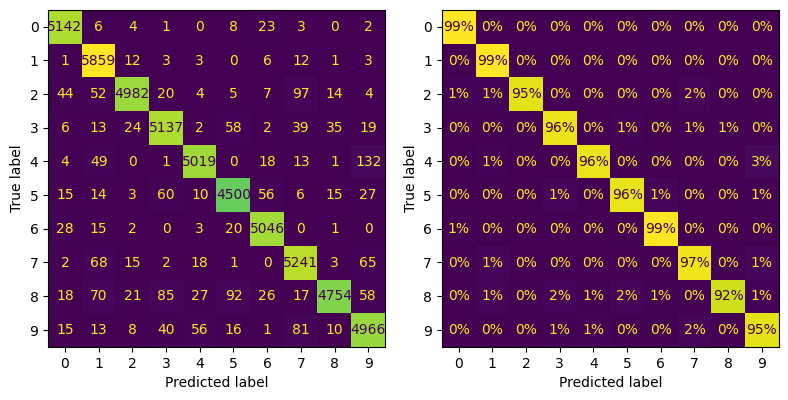

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_train, clf_predict_train)
figs, axes = plt.subplots(1,2, figsize=(8,12))
ConfusionMatrixDisplay.from_predictions(y_train, clf_predict_train, ax=axes[0], colorbar=False)
ConfusionMatrixDisplay.from_predictions(y_train, clf_predict_train, normalize="true", values_format=".0%", ax=axes[1], colorbar=False)
plt.tight_layout()
plt.show()

In [26]:
from sklearn.metrics import f1_score

f1_score(y_train, clf_predict_train, average='weighted')

0.9646209502471389

In [27]:
from sklearn.metrics import accuracy_score
accuracy_score(y_train, clf_predict_train)

0.9646857142857143

# Data augmentation

In [30]:
type(X_train)

numpy.ndarray

In [31]:
X_train.shape

(52500, 784)

In [42]:
def shift_pixel(data:np.ndarray) -> np.ndarray:
    image = data.reshape(-1, 28,28)
    shifted_img = [left(image), right(image), up(image), down(image)]
    result = []
    for imgs in shifted_img:
        imgs = imgs.reshape(-1, 28*28)
        result.append(imgs)
    
    result = np.concatenate(result, axis=0)
    return result

def left(images:np.ndarray) -> np.ndarray:
    result = images.copy()
    result[:,:,:-1] = images[:,:,1:]
    result[:,:,-1] = 0
    return result

def right(images:np.ndarray) -> np.ndarray:
    result = images.copy()
    result[:,:,1:] = images[:,:,:-1]
    result[:,:,0] = 0
    return result

def up(images:np.ndarray) -> np.ndarray:
    result = images.copy()
    result[:,:-1,:] = images[:,1:,:]
    result[:,-1,:] = 0
    return result

def down(images:np.ndarray) -> np.ndarray:
    result = images.copy()
    result[:,1:,:] = images[:,:-1,:]
    result[:,0,:] = 0
    return result

In [51]:
augmented_X_data = np.concatenate([shift_pixel(X_train), X_train], axis=0)
augmented_y_data = np.tile(y_train, 5) #1 for original, 4 for left right up down.

rng = np.random.default_rng(seed=42)
shupple_idx = rng.permutation(len(augmented_X_data))
augmented_X_data = augmented_X_data[shupple_idx]
augmented_y_data = augmented_y_data[shupple_idx]

In [52]:
clf_aug = KNeighborsClassifier(n_neighbors=3)
clf_aug_y_train_predict = cross_val_predict(clf_aug, augmented_X_data, augmented_y_data, cv=3, n_jobs=-1)

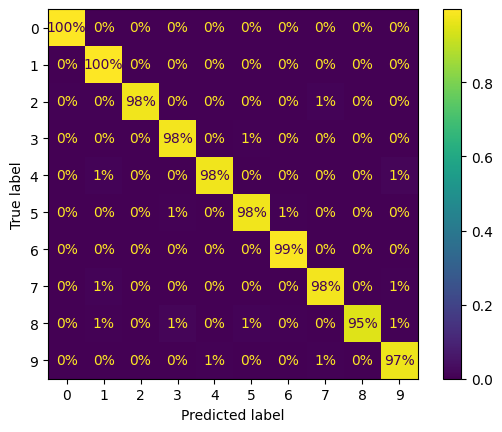

In [56]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(augmented_y_data, clf_aug_y_train_predict, normalize="true", values_format=".0%")
plt.show()

In [57]:
import pickle

with open("clf_aug.pkl", "wb") as f:
    pickle.dump(clf_aug, f)

with open("clf_aug_y_train_predict.pkl", "wb") as f:
    pickle.dump(clf_aug_y_train_predict, f)